In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybamm

pybamm.set_logging_level("WARNING")

print("PyBaMM version:", pybamm.__version__)

PyBaMM version: 26.3.1


In [2]:
def make_experiment(discharge_min=20, rest_min=10):
    return pybamm.Experiment(
        [
            pybamm.step.string(
                f"Discharge at 1C for {discharge_min} minutes",
                period="1 second",
            ),
            pybamm.step.string(
                f"Rest for {rest_min} minutes",
                period="0.1 second",
            ),
        ]
    )

experiment = make_experiment()
experiment

pybamm.Experiment([(Step(1.0, duration=20 minutes, period=1 second, description=Discharge at 1C for 20 minutes),), (Step(0, duration=10 minutes, period=0.1 second, description=Rest for 10 minutes),)])

In [3]:
def make_model():
    return pybamm.lithium_ion.DFN({"SEI": "constant"})

def make_base_params():
    return pybamm.ParameterValues("Chen2020")

model = make_model()
params = make_base_params()

print(type(model))
print(type(params))

<class 'pybamm.models.full_battery_models.lithium_ion.dfn.DFN'>
<class 'pybamm.parameters.parameter_values.ParameterValues'>


In [4]:
sim_healthy = pybamm.Simulation(
    model,
    parameter_values=params,
    experiment=experiment,
)

solution_healthy = sim_healthy.solve()
print("Solved healthy baseline.")

Solved healthy baseline.


In [5]:
sim_healthy.plot()
plt.show()

ModuleNotFoundError: No module named 'ipywidgets'

In [6]:
%pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)
  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)
Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)
Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)

   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]

Note: you may need to restart the kernel to use updated packages.


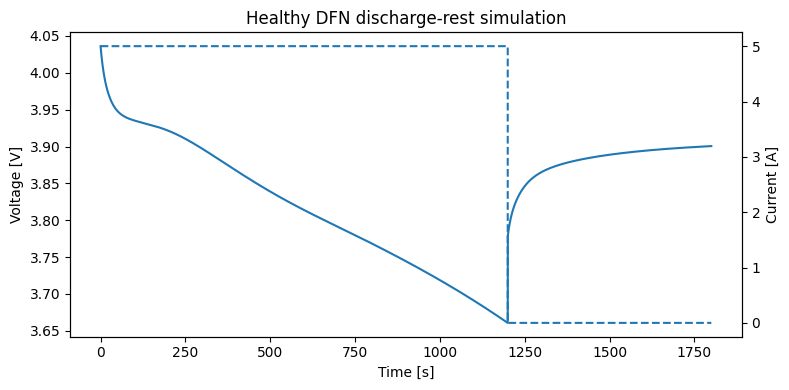

In [7]:
t = solution_healthy["Time [s]"].entries
V = solution_healthy["Voltage [V]"].entries
I = solution_healthy["Current [A]"].entries

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(t, V, label="Voltage [V]")
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("Voltage [V]")

ax2 = ax1.twinx()
ax2.plot(t, I, linestyle="--", label="Current [A]")
ax2.set_ylabel("Current [A]")

plt.title("Healthy DFN discharge-rest simulation")
plt.tight_layout()
plt.show()

In [8]:
def detect_rest_start(solution, current_tol=1e-10):
    t = solution["Time [s]"].entries
    I = solution["Current [A]"].entries
    zero_idx = np.where(np.abs(I) < current_tol)[0]
    if len(zero_idx) == 0:
        raise RuntimeError("Could not detect start of rest step from current trace.")
    return t[zero_idx[0]]

def extract_rest_window(solution, rest_window_s=120):
    t = solution["Time [s]"].entries
    V = solution["Voltage [V]"].entries
    rest_start = detect_rest_start(solution)

    mask = (t >= rest_start) & (t <= rest_start + rest_window_s)
    rest_t = t[mask] - rest_start
    rest_V = V[mask]

    return rest_t, rest_V, rest_start

rest_t_h, rest_V_h, rest_start_h = extract_rest_window(solution_healthy, 120)

print(f"Rest starts at {rest_start_h:.2f} s")
print(f"Points in first 120 s of rest: {len(rest_t_h)}")
print(f"Voltage at start of rest: {rest_V_h[0]:.4f} V")
print(f"Voltage at end of 120 s rest window: {rest_V_h[-1]:.4f} V")

Rest starts at 1200.00 s
Points in first 120 s of rest: 1201
Voltage at start of rest: 3.7771 V
Voltage at end of 120 s rest window: 3.8699 V


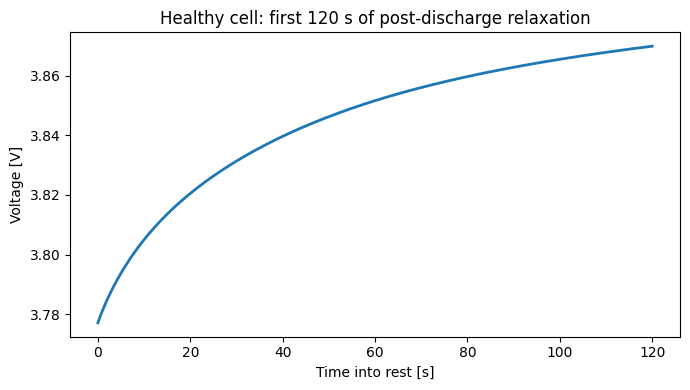

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(rest_t_h, rest_V_h, lw=2)
plt.xlabel("Time into rest [s]")
plt.ylabel("Voltage [V]")
plt.title("Healthy cell: first 120 s of post-discharge relaxation")
plt.tight_layout()
plt.show()

In [10]:
np.savez(
    "../outputs/healthy_rest_first_120s.npz",
    time_s=rest_t_h,
    voltage_V=rest_V_h,
    rest_start_s=rest_start_h,
)
print("Saved healthy rest trace to outputs/")

Saved healthy rest trace to outputs/


In [14]:
def interp_at(x, y, xq):
    return np.interp(xq, x, y)

def safe_linear_slope(x, y):
    if len(x) < 2:
        return np.nan
    return np.polyfit(x, y, 1)[0]

def compute_features(rest_t, rest_V, window_s):
    mask = rest_t <= window_s
    t = rest_t[mask]
    V = rest_V[mask]

    if len(t) < 2:
        return {
            "window_s": window_s,
            "fast_recovery_5s_V": np.nan,
            "initial_slope_0_5_V_per_s": np.nan,
            "relaxation_area_Vs": np.nan,
        }

    t_fast_end = min(5.0, t[-1])
    fast_recovery = interp_at(t, V, t_fast_end) - V[0]

    mask_fast = t <= t_fast_end
    slope_0_5 = safe_linear_slope(t[mask_fast], V[mask_fast])

    area = np.trapezoid(V - V[0], t)

    return {
        "window_s": window_s,
        "fast_recovery_5s_V": fast_recovery,
        "initial_slope_0_5_V_per_s": slope_0_5,
        "relaxation_area_Vs": area,
    }

def compute_all_windows(rest_t, rest_V, windows_s=[5, 10, 30, 60, 120]):
    return pd.DataFrame([compute_features(rest_t, rest_V, w) for w in windows_s])

In [15]:
features_h = compute_all_windows(rest_t_h, rest_V_h)
features_h["label"] = "healthy"
features_h["delta_q_ah"] = 0.0
features_h

,window_s,fast_recovery_5s_V,initial_slope_0_5_V_per_s,relaxation_area_Vs,label,delta_q_ah
0,5,0.016659,0.003292,0.045241,healthy,0.0
1,10,0.016659,0.003292,0.158046,healthy,0.0
2,30,0.016659,0.003292,1.010557,healthy,0.0
3,60,0.016659,0.003292,2.974103,healthy,0.0
4,120,0.016659,0.003292,8.073539,healthy,0.0


In [16]:
features_h.to_csv("../outputs/healthy_features.csv", index=False)
print("Saved healthy features.")

Saved healthy features.


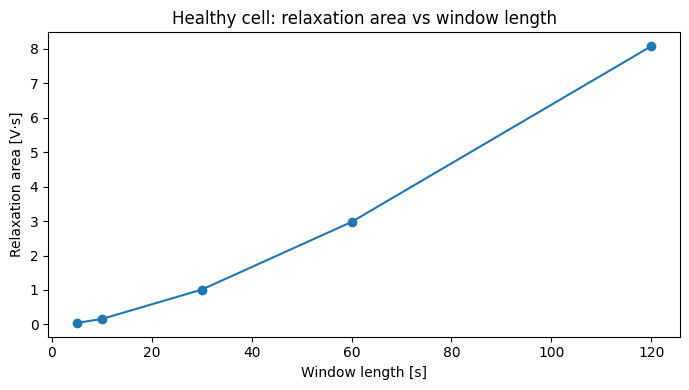

In [17]:
plt.figure(figsize=(7, 4))
plt.plot(features_h["window_s"], features_h["relaxation_area_Vs"], marker="o")
plt.xlabel("Window length [s]")
plt.ylabel("Relaxation area [V·s]")
plt.title("Healthy cell: relaxation area vs window length")
plt.tight_layout()
plt.show()

In [18]:
def make_storage_loss_params(delta_q_ah):
    param = make_base_params()

    c_init_n = param["Initial concentration in negative electrode [mol.m-3]"]
    L_SEI_0 = param["Initial SEI thickness [m]"]
    eps_neg = param["Negative electrode porosity"]

    F = 96485.3
    L_n = param["Negative electrode thickness [m]"]
    L_y = param["Electrode width [m]"]
    L_z = param["Electrode height [m]"]
    V_n = L_n * L_y * L_z

    R_n = param["Negative particle radius [m]"]
    eps_act_n = param["Negative electrode active material volume fraction"]
    a_n = 3 * eps_act_n / R_n

    V_bar_SEI = param["SEI partial molar volume [m3.mol-1]"]
    z_SEI = param["Ratio of lithium moles to SEI moles"]

    c_SEI = delta_q_ah * 3600 / (F * z_SEI * V_n)
    delta_c_n = c_SEI * z_SEI / eps_act_n

    c_init_degraded = c_init_n - delta_c_n
    L_SEI_0_degraded = L_SEI_0 + c_SEI * V_bar_SEI / a_n
    eps_neg_degraded = eps_neg - (L_SEI_0_degraded - L_SEI_0) * a_n

    param_degraded = param.copy()
    param_degraded.update(
        {
            "Initial concentration in negative electrode [mol.m-3]": c_init_degraded,
            "Initial SEI thickness [m]": L_SEI_0_degraded,
            "Negative electrode porosity": eps_neg_degraded,
        }
    )

    return param_degraded

In [19]:
delta_q_test = 0.135
print("Using degraded test case with ΔQ =", delta_q_test, "Ah")

Using degraded test case with ΔQ = 0.135 Ah


In [20]:
sim_deg = pybamm.Simulation(
    make_model(),
    parameter_values=make_storage_loss_params(delta_q_test),
    experiment=make_experiment(),
)

solution_deg = sim_deg.solve()
print("Solved degraded case.")

Solved degraded case.


In [21]:
rest_t_deg, rest_V_deg, rest_start_deg = extract_rest_window(solution_deg, 120)

print(f"Degraded rest starts at {rest_start_deg:.2f} s")
print(f"Points in first 120 s of degraded rest: {len(rest_t_deg)}")
print(f"Voltage at start of degraded rest: {rest_V_deg[0]:.4f} V")
print(f"Voltage at end of degraded 120 s rest window: {rest_V_deg[-1]:.4f} V")

Degraded rest starts at 1200.00 s
Points in first 120 s of degraded rest: 1201
Voltage at start of degraded rest: 3.7646 V
Voltage at end of degraded 120 s rest window: 3.8616 V


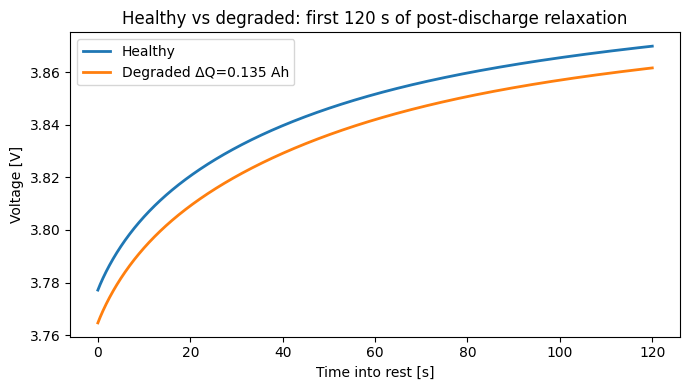

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(rest_t_h, rest_V_h, label="Healthy", lw=2)
plt.plot(rest_t_deg, rest_V_deg, label=f"Degraded ΔQ={delta_q_test:.3f} Ah", lw=2)
plt.xlabel("Time into rest [s]")
plt.ylabel("Voltage [V]")
plt.title("Healthy vs degraded: first 120 s of post-discharge relaxation")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
features_deg = compute_all_windows(rest_t_deg, rest_V_deg)
features_deg["label"] = f"storage_loss_{delta_q_test:.3f}Ah"
features_deg["delta_q_ah"] = delta_q_test
features_deg

,window_s,fast_recovery_5s_V,initial_slope_0_5_V_per_s,relaxation_area_Vs,label,delta_q_ah
0,5,0.017002,0.003361,0.046109,storage_loss_0.135Ah,0.135
1,10,0.017002,0.003361,0.161384,storage_loss_0.135Ah,0.135
2,30,0.017002,0.003361,1.035935,storage_loss_0.135Ah,0.135
3,60,0.017002,0.003361,3.064585,storage_loss_0.135Ah,0.135
4,120,0.017002,0.003361,8.384551,storage_loss_0.135Ah,0.135


In [24]:
comparison_df = pd.concat([features_h, features_deg], ignore_index=True)
comparison_df

,window_s,fast_recovery_5s_V,initial_slope_0_5_V_per_s,relaxation_area_Vs,label,delta_q_ah
0,5,0.016659,0.003292,0.045241,healthy,0.000
1,10,0.016659,0.003292,0.158046,healthy,0.000
2,30,0.016659,0.003292,1.010557,healthy,0.000
3,60,0.016659,0.003292,2.974103,healthy,0.000
4,120,0.016659,0.003292,8.073539,healthy,0.000
5,5,0.017002,0.003361,0.046109,storage_loss_0.135Ah,0.135
6,10,0.017002,0.003361,0.161384,storage_loss_0.135Ah,0.135
7,30,0.017002,0.003361,1.035935,storage_loss_0.135Ah,0.135
8,60,0.017002,0.003361,3.064585,storage_loss_0.135Ah,0.135
9,120,0.017002,0.003361,8.384551,storage_loss_0.135Ah,0.135


In [25]:
comparison_pivot = comparison_df.pivot(
    index="window_s",
    columns="label",
    values=["fast_recovery_5s_V", "initial_slope_0_5_V_per_s", "relaxation_area_Vs"]
)

comparison_pivot

fast_recovery_5s_V                      initial_slope_0_5_V_per_s  \
label               healthy storage_loss_0.135Ah                   healthy   
window_s                                                                     
5                  0.016659             0.017002                  0.003292   
10                 0.016659             0.017002                  0.003292   
30                 0.016659             0.017002                  0.003292   
60                 0.016659             0.017002                  0.003292   
120                0.016659             0.017002                  0.003292   

                              relaxation_area_Vs                       
label    storage_loss_0.135Ah            healthy storage_loss_0.135Ah  
window_s                                                               
5                    0.003361           0.045241             0.046109  
10                   0.003361           0.158046             0.161384  
30                   0.003361           1.010557             1.035935  
60                   0.003361           2.974103             3.064585  
120                  0.003361           8.073539             8.384551

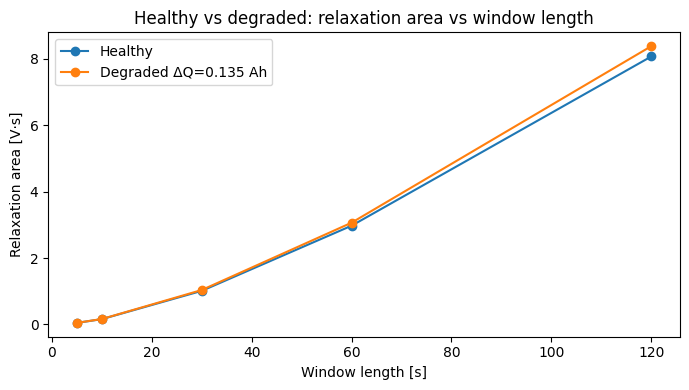

In [26]:
plt.figure(figsize=(7, 4))

plt.plot(
    features_h["window_s"],
    features_h["relaxation_area_Vs"],
    marker="o",
    label="Healthy"
)

plt.plot(
    features_deg["window_s"],
    features_deg["relaxation_area_Vs"],
    marker="o",
    label=f"Degraded ΔQ={delta_q_test:.3f} Ah"
)

plt.xlabel("Window length [s]")
plt.ylabel("Relaxation area [V·s]")
plt.title("Healthy vs degraded: relaxation area vs window length")
plt.legend()
plt.tight_layout()
plt.show()

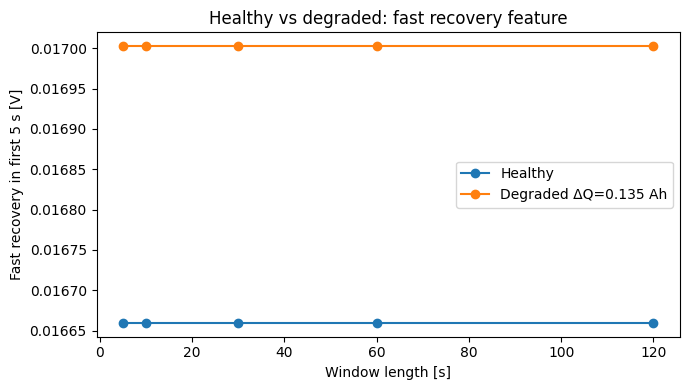

In [27]:
plt.figure(figsize=(7, 4))

plt.plot(
    features_h["window_s"],
    features_h["fast_recovery_5s_V"],
    marker="o",
    label="Healthy"
)

plt.plot(
    features_deg["window_s"],
    features_deg["fast_recovery_5s_V"],
    marker="o",
    label=f"Degraded ΔQ={delta_q_test:.3f} Ah"
)

plt.xlabel("Window length [s]")
plt.ylabel("Fast recovery in first 5 s [V]")
plt.title("Healthy vs degraded: fast recovery feature")
plt.legend()
plt.tight_layout()
plt.show()

In [28]:
features_deg.to_csv("../outputs/degraded_features_single_case.csv", index=False)
comparison_df.to_csv("../outputs/healthy_vs_degraded_single_case.csv", index=False)
print("Saved degraded features and comparison table.")

Saved degraded features and comparison table.


In [29]:
delta_q_levels = [0.00, 0.05, 0.10, 0.135, 0.20]
feature_rows = []

for delta_q in delta_q_levels:
    sim = pybamm.Simulation(
        make_model(),
        parameter_values=make_storage_loss_params(delta_q),
        experiment=make_experiment(),
    )
    sol = sim.solve()

    rest_t, rest_V, rest_start = extract_rest_window(sol, 120)

    feat = compute_all_windows(rest_t, rest_V)
    feat["label"] = f"storage_loss_{delta_q:.3f}Ah"
    feat["delta_q_ah"] = delta_q
    feature_rows.append(feat)

feature_sweep_df = pd.concat(feature_rows, ignore_index=True)
feature_sweep_df

,window_s,fast_recovery_5s_V,initial_slope_0_5_V_per_s,relaxation_area_Vs,label,delta_q_ah
0,5,0.016659,0.003292,0.045241,storage_loss_0.000Ah,0.000
1,10,0.016659,0.003292,0.158046,storage_loss_0.000Ah,0.000
2,30,0.016659,0.003292,1.010557,storage_loss_0.000Ah,0.000
3,60,0.016659,0.003292,2.974103,storage_loss_0.000Ah,0.000
4,120,0.016659,0.003292,8.073539,storage_loss_0.000Ah,0.000
5,5,0.016896,0.003338,0.045910,storage_loss_0.050Ah,0.050
6,10,0.016896,0.003338,0.160271,storage_loss_0.050Ah,0.050
7,30,0.016896,0.003338,1.024251,storage_loss_0.050Ah,0.050
8,60,0.016896,0.003338,3.017468,storage_loss_0.050Ah,0.050
9,120,0.016896,0.003338,8.206926,storage_loss_0.050Ah,0.050


In [30]:
feature_sweep_df.to_csv("../outputs/feature_sweep_storage_loss.csv", index=False)
print("Saved feature sweep table.")

Saved feature sweep table.


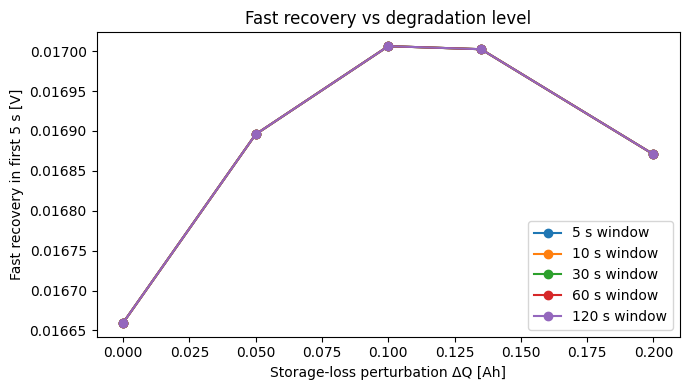

In [31]:
plt.figure(figsize=(7, 4))

for window_s, sub in feature_sweep_df.groupby("window_s"):
    sub = sub.sort_values("delta_q_ah")
    plt.plot(
        sub["delta_q_ah"],
        sub["fast_recovery_5s_V"],
        marker="o",
        label=f"{window_s} s window"
    )

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Fast recovery in first 5 s [V]")
plt.title("Fast recovery vs degradation level")
plt.legend()
plt.tight_layout()
plt.show()

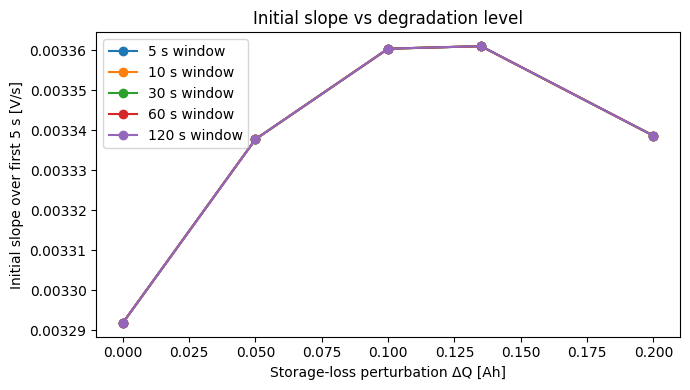

In [32]:
plt.figure(figsize=(7, 4))

for window_s, sub in feature_sweep_df.groupby("window_s"):
    sub = sub.sort_values("delta_q_ah")
    plt.plot(
        sub["delta_q_ah"],
        sub["initial_slope_0_5_V_per_s"],
        marker="o",
        label=f"{window_s} s window"
    )

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Initial slope over first 5 s [V/s]")
plt.title("Initial slope vs degradation level")
plt.legend()
plt.tight_layout()
plt.show()

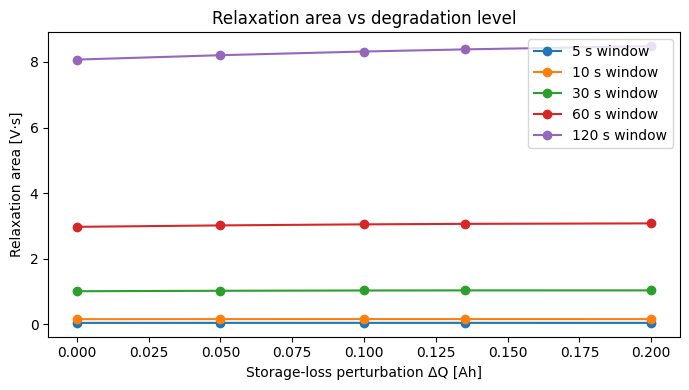

In [33]:
plt.figure(figsize=(7, 4))

for window_s, sub in feature_sweep_df.groupby("window_s"):
    sub = sub.sort_values("delta_q_ah")
    plt.plot(
        sub["delta_q_ah"],
        sub["relaxation_area_Vs"],
        marker="o",
        label=f"{window_s} s window"
    )

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Relaxation area [V·s]")
plt.title("Relaxation area vs degradation level")
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
pivot_sweep = feature_sweep_df.pivot_table(
    index="delta_q_ah",
    columns="window_s",
    values=["fast_recovery_5s_V", "initial_slope_0_5_V_per_s", "relaxation_area_Vs"]
)

pivot_sweep

fast_recovery_5s_V                                          \
window_s                  5         10        30        60        120   
delta_q_ah                                                              
0.000                0.016659  0.016659  0.016659  0.016659  0.016659   
0.050                0.016896  0.016896  0.016896  0.016896  0.016896   
0.100                0.017006  0.017006  0.017006  0.017006  0.017006   
0.135                0.017002  0.017002  0.017002  0.017002  0.017002   
0.200                0.016871  0.016871  0.016871  0.016871  0.016871   

           initial_slope_0_5_V_per_s                                          \
window_s                         5         10        30        60        120   
delta_q_ah                                                                     
0.000                       0.003292  0.003292  0.003292  0.003292  0.003292   
0.050                       0.003338  0.003338  0.003338  0.003338  0.003338   
0.100                       0.003360  0.003360  0.003360  0.003360  0.003360   
0.135                       0.003361  0.003361  0.003361  0.003361  0.003361   
0.200                       0.003339  0.003339  0.003339  0.003339  0.003339   

           relaxation_area_Vs                                          
window_s                  5         10        30        60        120  
delta_q_ah                                                             
0.000                0.045241  0.158046  1.010557  2.974103  8.073539  
0.050                0.045910  0.160271  1.024251  3.017468  8.206926  
0.100                0.046176  0.161360  1.033084  3.049667  8.319604  
0.135                0.046109  0.161384  1.035935  3.064585  8.384551  
0.200                0.045608  0.160289  1.035769  3.079242  8.482443

In [49]:
def interp_at(x, y, xq):
    return np.interp(xq, x, y)

def safe_linear_slope(x, y):
    if len(x) < 2:
        return np.nan
    return np.polyfit(x, y, 1)[0]

def safe_log_time_slope(t, V):
    if len(t) < 2:
        return np.nan
    x = np.log1p(t)   # log(1+t) avoids log(0)
    return np.polyfit(x, V, 1)[0]

def compute_features(rest_t, rest_V, window_s):
    mask = rest_t <= window_s
    t = rest_t[mask]
    V = rest_V[mask]

    if len(t) < 2:
        return {
            "window_s": window_s,
            "fast_recovery_5s_V": np.nan,
            "initial_slope_0_5_V_per_s": np.nan,
            "log_time_slope_5_30_V_per_log_s": np.nan,
            "relaxation_area_Vs": np.nan,
        }

    # Fast feature
    t_fast_end = min(5.0, t[-1])
    fast_recovery = interp_at(t, V, t_fast_end) - V[0]

    mask_fast = t <= t_fast_end
    slope_0_5 = safe_linear_slope(t[mask_fast], V[mask_fast])

    # Intermediate feature: log-time slope from 5 to 30 s
    if t[-1] >= 30:
        mask_mid = (t >= 5.0) & (t <= 30.0)
        log_slope_5_30 = safe_log_time_slope(t[mask_mid], V[mask_mid])
    else:
        log_slope_5_30 = np.nan

    # Cumulative feature
    area = np.trapezoid(V - V[0], t)

    return {
        "window_s": window_s,
        "fast_recovery_5s_V": fast_recovery,
        "initial_slope_0_5_V_per_s": slope_0_5,
        "log_time_slope_5_30_V_per_log_s": log_slope_5_30,
        "relaxation_area_Vs": area,
    }

def compute_all_windows(rest_t, rest_V, windows_s=[5, 10, 30, 60, 120]):
    return pd.DataFrame([compute_features(rest_t, rest_V, w) for w in windows_s])

In [50]:
def interp_at(x, y, xq):
    return np.interp(xq, x, y)

def safe_linear_slope(x, y):
    if len(x) < 2:
        return np.nan
    return np.polyfit(x, y, 1)[0]

def safe_log_time_slope(t, V):
    if len(t) < 2:
        return np.nan
    x = np.log1p(t)
    return np.polyfit(x, V, 1)[0]

def compute_features(rest_t, rest_V, window_s, tol=1e-9):
    mask = rest_t <= window_s + tol
    t = rest_t[mask]
    V = rest_V[mask]

    if len(t) < 2:
        return {
            "window_s": window_s,
            "fast_recovery_5s_V": np.nan,
            "initial_slope_0_5_V_per_s": np.nan,
            "log_time_slope_5_30_V_per_log_s": np.nan,
            "relaxation_area_Vs": np.nan,
        }

    # Fast feature
    t_fast_end = min(5.0, t[-1])
    fast_recovery = interp_at(t, V, t_fast_end) - V[0]

    mask_fast = t <= t_fast_end + tol
    slope_0_5 = safe_linear_slope(t[mask_fast], V[mask_fast])

    # Intermediate feature: 5–30 s
    if t[-1] >= 30.0 - tol:
        mask_mid = (t >= 5.0 - tol) & (t <= 30.0 + tol)
        log_slope_5_30 = safe_log_time_slope(t[mask_mid], V[mask_mid])
    else:
        log_slope_5_30 = np.nan

    # Cumulative feature
    area = np.trapezoid(V - V[0], t)

    return {
        "window_s": window_s,
        "fast_recovery_5s_V": fast_recovery,
        "initial_slope_0_5_V_per_s": slope_0_5,
        "log_time_slope_5_30_V_per_log_s": log_slope_5_30,
        "relaxation_area_Vs": area,
    }

def compute_all_windows(rest_t, rest_V, windows_s=[5, 10, 30, 60, 120]):
    return pd.DataFrame([compute_features(rest_t, rest_V, w) for w in windows_s])

In [51]:
features_h = compute_all_windows(rest_t_h, rest_V_h)
features_h["label"] = "healthy"
features_h["delta_q_ah"] = 0.0
features_h

,window_s,fast_recovery_5s_V,initial_slope_0_5_V_per_s,log_time_slope_5_30_V_per_log_s,relaxation_area_Vs,label,delta_q_ah
0,5,0.016659,0.003292,NaN,0.045241,healthy,0.0
1,10,0.016659,0.003292,NaN,0.158046,healthy,0.0
2,30,0.016659,0.003292,0.023689,1.010557,healthy,0.0
3,60,0.016659,0.003292,0.023689,2.974103,healthy,0.0
4,120,0.016659,0.003292,0.023689,8.073539,healthy,0.0


In [52]:
features_deg = compute_all_windows(rest_t_deg, rest_V_deg)
features_deg["label"] = f"storage_loss_{delta_q_test:.3f}Ah"
features_deg["delta_q_ah"] = delta_q_test
features_deg

,window_s,fast_recovery_5s_V,initial_slope_0_5_V_per_s,log_time_slope_5_30_V_per_log_s,relaxation_area_Vs,label,delta_q_ah
0,5,0.017002,0.003361,NaN,0.046109,storage_loss_0.135Ah,0.135
1,10,0.017002,0.003361,NaN,0.161384,storage_loss_0.135Ah,0.135
2,30,0.017002,0.003361,0.024434,1.035935,storage_loss_0.135Ah,0.135
3,60,0.017002,0.003361,0.024434,3.064585,storage_loss_0.135Ah,0.135
4,120,0.017002,0.003361,0.024434,8.384551,storage_loss_0.135Ah,0.135


In [53]:
delta_q_levels = [0.00, 0.05, 0.10, 0.135, 0.20]
feature_rows = []

for delta_q in delta_q_levels:
    sim = pybamm.Simulation(
        make_model(),
        parameter_values=make_storage_loss_params(delta_q),
        experiment=make_experiment(),
    )
    sol = sim.solve()

    rest_t, rest_V, rest_start = extract_rest_window(sol, 120)

    feat = compute_all_windows(rest_t, rest_V)
    feat["label"] = f"storage_loss_{delta_q:.3f}Ah"
    feat["delta_q_ah"] = delta_q
    feature_rows.append(feat)

feature_sweep_df = pd.concat(feature_rows, ignore_index=True)
feature_sweep_df

,window_s,fast_recovery_5s_V,initial_slope_0_5_V_per_s,log_time_slope_5_30_V_per_log_s,relaxation_area_Vs,label,delta_q_ah
0,5,0.016659,0.003292,NaN,0.045241,storage_loss_0.000Ah,0.000
1,10,0.016659,0.003292,NaN,0.158046,storage_loss_0.000Ah,0.000
2,30,0.016659,0.003292,0.023689,1.010557,storage_loss_0.000Ah,0.000
3,60,0.016659,0.003292,0.023689,2.974103,storage_loss_0.000Ah,0.000
4,120,0.016659,0.003292,0.023689,8.073539,storage_loss_0.000Ah,0.000
5,5,0.016896,0.003338,NaN,0.045910,storage_loss_0.050Ah,0.050
6,10,0.016896,0.003338,NaN,0.160271,storage_loss_0.050Ah,0.050
7,30,0.016896,0.003338,0.024006,1.024251,storage_loss_0.050Ah,0.050
8,60,0.016896,0.003338,0.024006,3.017468,storage_loss_0.050Ah,0.050
9,120,0.016896,0.003338,0.024006,8.206926,storage_loss_0.050Ah,0.050


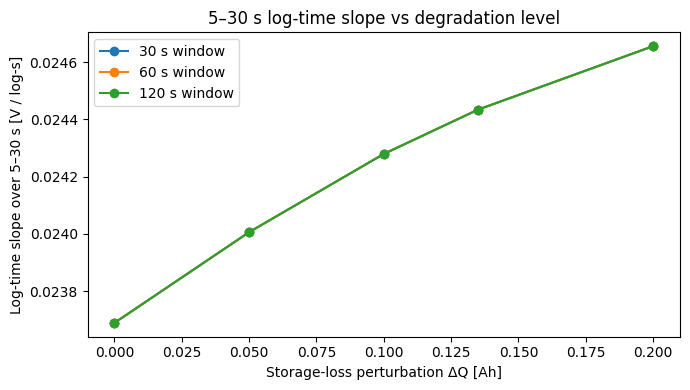

In [54]:
plt.figure(figsize=(7, 4))

sub = feature_sweep_df[feature_sweep_df["window_s"].isin([30, 60, 120])]

for window_s, grp in sub.groupby("window_s"):
    grp = grp.sort_values("delta_q_ah")
    plt.plot(
        grp["delta_q_ah"],
        grp["log_time_slope_5_30_V_per_log_s"],
        marker="o",
        label=f"{window_s} s window"
    )

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Log-time slope over 5–30 s [V / log-s]")
plt.title("5–30 s log-time slope vs degradation level")
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
pivot_sweep = feature_sweep_df.pivot_table(
    index="delta_q_ah",
    columns="window_s",
    values=[
        "fast_recovery_5s_V",
        "initial_slope_0_5_V_per_s",
        "log_time_slope_5_30_V_per_log_s",
        "relaxation_area_Vs",
    ]
)

pivot_sweep

fast_recovery_5s_V                                          \
window_s                  5         10        30        60        120   
delta_q_ah                                                              
0.000                0.016659  0.016659  0.016659  0.016659  0.016659   
0.050                0.016896  0.016896  0.016896  0.016896  0.016896   
0.100                0.017006  0.017006  0.017006  0.017006  0.017006   
0.135                0.017002  0.017002  0.017002  0.017002  0.017002   
0.200                0.016871  0.016871  0.016871  0.016871  0.016871   

           initial_slope_0_5_V_per_s                                          \
window_s                         5         10        30        60        120   
delta_q_ah                                                                     
0.000                       0.003292  0.003292  0.003292  0.003292  0.003292   
0.050                       0.003338  0.003338  0.003338  0.003338  0.003338   
0.100                       0.003360  0.003360  0.003360  0.003360  0.003360   
0.135                       0.003361  0.003361  0.003361  0.003361  0.003361   
0.200                       0.003339  0.003339  0.003339  0.003339  0.003339   

           log_time_slope_5_30_V_per_log_s                      \
window_s                               30        60        120   
delta_q_ah                                                       
0.000                             0.023689  0.023689  0.023689   
0.050                             0.024006  0.024006  0.024006   
0.100                             0.024279  0.024279  0.024279   
0.135                             0.024434  0.024434  0.024434   
0.200                             0.024655  0.024655  0.024655   

           relaxation_area_Vs                                          
window_s                  5         10        30        60        120  
delta_q_ah                                                             
0.000                0.045241  0.158046  1.010557  2.974103  8.073539  
0.050                0.045910  0.160271  1.024251  3.017468  8.206926  
0.100                0.046176  0.161360  1.033084  3.049667  8.319604  
0.135                0.046109  0.161384  1.035935  3.064585  8.384551  
0.200                0.045608  0.160289  1.035769  3.079242  8.482443

In [56]:
COMPONENT_KEYS = {
    "Battery OCV [V]": "Battery open-circuit voltage [V]",
    "Reaction overpotential [V]": "X-averaged battery reaction overpotential [V]",
    "Solid ohmic losses [V]": "X-averaged battery solid phase ohmic losses [V]",
    "Electrolyte ohmic losses [V]": "X-averaged battery electrolyte ohmic losses [V]",
    "Concentration overpotential [V]": "X-averaged battery concentration overpotential [V]",
    "Battery voltage [V]": "Battery voltage [V]",
}

In [57]:
def extract_component_rest_window(solution, rest_window_s=120):
    t = solution["Time [s]"].entries
    rest_start = detect_rest_start(solution)
    mask = (t >= rest_start) & (t <= rest_start + rest_window_s)
    rest_t = t[mask] - rest_start

    out = {"time_s": rest_t}
    for pretty_name, key in COMPONENT_KEYS.items():
        out[pretty_name] = solution[key].entries[mask]
    return out

In [58]:
comp_h = extract_component_rest_window(solution_healthy, 120)
comp_deg = extract_component_rest_window(solution_deg, 120)

list(comp_h.keys())

['time_s',
 'Battery OCV [V]',
 'Reaction overpotential [V]',
 'Solid ohmic losses [V]',
 'Electrolyte ohmic losses [V]',
 'Concentration overpotential [V]',
 'Battery voltage [V]']

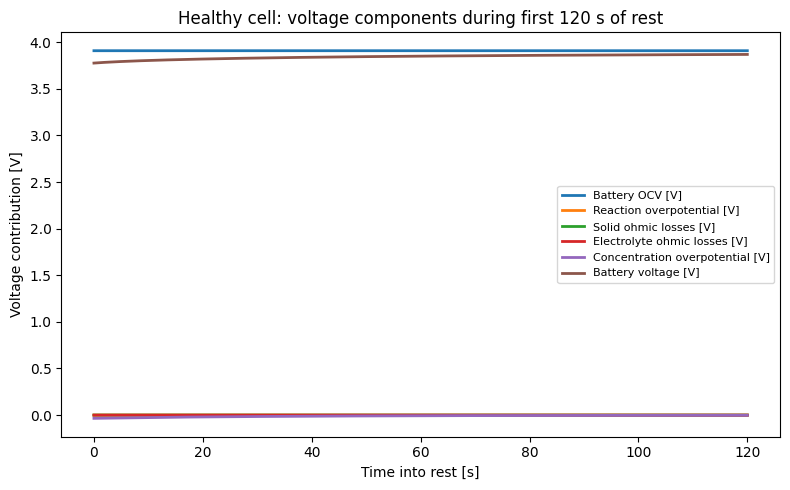

In [59]:
plt.figure(figsize=(8, 5))
for k, v in comp_h.items():
    if k == "time_s":
        continue
    plt.plot(comp_h["time_s"], v, label=k, lw=2)

plt.xlabel("Time into rest [s]")
plt.ylabel("Voltage contribution [V]")
plt.title("Healthy cell: voltage components during first 120 s of rest")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

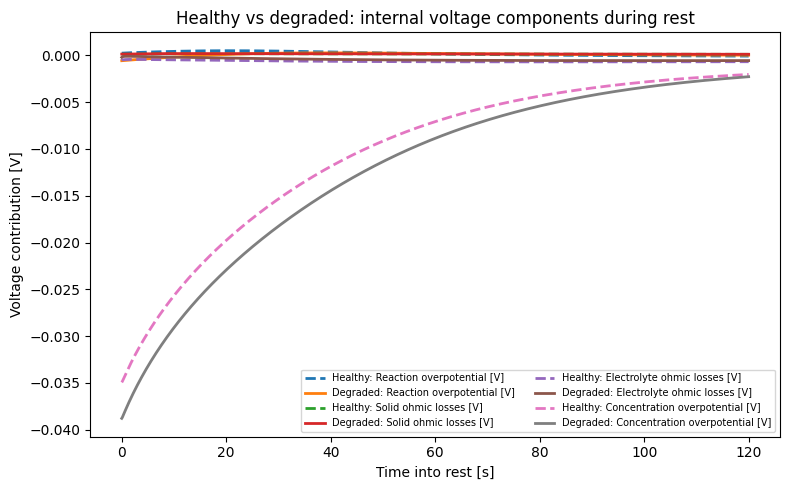

In [60]:
plt.figure(figsize=(8, 5))

for key in [
    "Reaction overpotential [V]",
    "Solid ohmic losses [V]",
    "Electrolyte ohmic losses [V]",
    "Concentration overpotential [V]",
]:
    plt.plot(comp_h["time_s"], comp_h[key], "--", lw=2, label=f"Healthy: {key}")
    plt.plot(comp_deg["time_s"], comp_deg[key], lw=2, label=f"Degraded: {key}")

plt.xlabel("Time into rest [s]")
plt.ylabel("Voltage contribution [V]")
plt.title("Healthy vs degraded: internal voltage components during rest")
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

In [61]:
comp_h_df = pd.DataFrame(comp_h)
comp_deg_df = pd.DataFrame(comp_deg)

comp_h_df.head()

,time_s,Battery OCV [V],Reaction overpotential [V],Solid ohmic losses [V],Electrolyte ohmic losses [V],Concentration overpotential [V],Battery voltage [V]
0,0.0,3.909751,0.000232,0.000117,-0.000554,-0.034939,3.777121
1,0.1,3.909751,0.000235,0.000117,-0.000499,-0.034853,3.777569
2,0.2,3.909751,0.000238,0.000117,-0.000482,-0.034732,3.778007
3,0.3,3.909751,0.000241,0.000117,-0.000472,-0.034607,3.778436
4,0.4,3.909751,0.000244,0.000117,-0.000465,-0.034482,3.778858


In [62]:
def component_summaries(comp_df):
    t = comp_df["time_s"].values

    summaries = {}

    for key in [
        "Reaction overpotential [V]",
        "Solid ohmic losses [V]",
        "Electrolyte ohmic losses [V]",
        "Concentration overpotential [V]",
    ]:
        y = comp_df[key].values
        summaries[f"{key}__start"] = y[0]
        summaries[f"{key}__end_5s"] = np.interp(5.0, t, y)
        summaries[f"{key}__end_30s"] = np.interp(30.0, t, y)
        summaries[f"{key}__drop_0_5s"] = y[0] - np.interp(5.0, t, y)
        summaries[f"{key}__drop_5_30s"] = np.interp(5.0, t, y) - np.interp(30.0, t, y)

    return pd.Series(summaries)

In [63]:
summary_compare = pd.DataFrame({
    "healthy": component_summaries(comp_h_df),
    "degraded": component_summaries(comp_deg_df),
})

summary_compare

,healthy,degraded
Reaction overpotential [V]__start,0.000232,-0.000575
Reaction overpotential [V]__end_5s,0.000345,-0.000367
Reaction overpotential [V]__end_30s,0.000453,0.000226
Reaction overpotential [V]__drop_0_5s,-0.000113,-0.000207
Reaction overpotential [V]__drop_5_30s,-0.000108,-0.000593
Solid ohmic losses [V]__start,0.000117,0.000131
Solid ohmic losses [V]__end_5s,0.000155,0.000169
Solid ohmic losses [V]__end_30s,0.000165,0.000170
Solid ohmic losses [V]__drop_0_5s,-0.000038,-0.000038
Solid ohmic losses [V]__drop_5_30s,-0.000010,-0.000002


In [64]:
component_rows = []

for delta_q in delta_q_levels:
    sim = pybamm.Simulation(
        make_model(),
        parameter_values=make_storage_loss_params(delta_q),
        experiment=make_experiment(),
    )
    sol = sim.solve()

    comp = extract_component_rest_window(sol, 120)
    comp_df = pd.DataFrame(comp)

    row = component_summaries(comp_df)
    row["delta_q_ah"] = delta_q
    component_rows.append(row)

component_sweep_df = pd.DataFrame(component_rows)
component_sweep_df

,Reaction overpotential [V]__start,Reaction overpotential [V]__end_5s,Reaction overpotential [V]__end_30s,Reaction overpotential [V]__drop_0_5s,Reaction overpotential [V]__drop_5_30s,Solid ohmic losses [V]__start,Solid ohmic losses [V]__end_5s,Solid ohmic losses [V]__end_30s,Solid ohmic losses [V]__drop_0_5s,Solid ohmic losses [V]__drop_5_30s,...,Electrolyte ohmic losses [V]__end_5s,Electrolyte ohmic losses [V]__end_30s,Electrolyte ohmic losses [V]__drop_0_5s,Electrolyte ohmic losses [V]__drop_5_30s,Concentration overpotential [V]__start,Concentration overpotential [V]__end_5s,Concentration overpotential [V]__end_30s,Concentration overpotential [V]__drop_0_5s,Concentration overpotential [V]__drop_5_30s,delta_q_ah
0,0.000232,0.000345,0.000453,-0.000113,-0.000108,0.000117,0.000155,0.000165,-0.000038,-0.000010,...,-0.000449,-0.000599,-0.000105,0.000150,-0.034939,-0.029638,-0.015341,-0.005302,-0.014296,0.000
1,-0.000036,0.000128,0.000413,-0.000163,-0.000285,0.000122,0.000160,0.000167,-0.000038,-0.000007,...,-0.000356,-0.000531,-0.000090,0.000175,-0.036218,-0.030828,-0.016305,-0.005390,-0.014523,0.050
2,-0.000347,-0.000150,0.000319,-0.000197,-0.000469,0.000127,0.000165,0.000169,-0.000038,-0.000004,...,-0.000237,-0.000443,-0.000078,0.000205,-0.037661,-0.032173,-0.017398,-0.005488,-0.014775,0.100
3,-0.000575,-0.000367,0.000226,-0.000207,-0.000593,0.000131,0.000169,0.000170,-0.000038,-0.000002,...,-0.000143,-0.000370,-0.000072,0.000227,-0.038783,-0.033222,-0.018254,-0.005561,-0.014968,0.135
4,-0.000991,-0.000793,0.000001,-0.000197,-0.000794,0.000139,0.000177,0.000174,-0.000037,0.000003,...,0.000053,-0.000216,-0.000070,0.000268,-0.041146,-0.035437,-0.020070,-0.005709,-0.015367,0.200


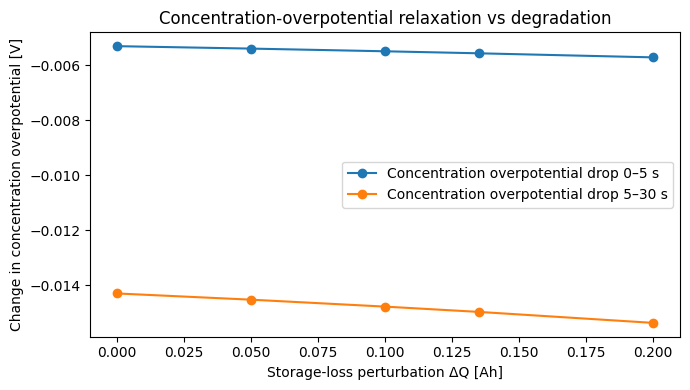

In [65]:
plt.figure(figsize=(7, 4))
plt.plot(
    component_sweep_df["delta_q_ah"],
    component_sweep_df["Concentration overpotential [V]__drop_0_5s"],
    marker="o",
    label="Concentration overpotential drop 0–5 s"
)
plt.plot(
    component_sweep_df["delta_q_ah"],
    component_sweep_df["Concentration overpotential [V]__drop_5_30s"],
    marker="o",
    label="Concentration overpotential drop 5–30 s"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.ylabel("Change in concentration overpotential [V]")
plt.title("Concentration-overpotential relaxation vs degradation")
plt.legend()
plt.tight_layout()
plt.show()

In [66]:
feature_30 = feature_sweep_df[feature_sweep_df["window_s"] == 30].copy()

comparison_mech = pd.merge(
    feature_30[["delta_q_ah", "log_time_slope_5_30_V_per_log_s"]],
    component_sweep_df[[
        "delta_q_ah",
        "Concentration overpotential [V]__drop_5_30s"
    ]],
    on="delta_q_ah"
)

comparison_mech

,delta_q_ah,log_time_slope_5_30_V_per_log_s,Concentration overpotential [V]__drop_5_30s
0,0.000,0.023689,-0.014296
1,0.050,0.024006,-0.014523
2,0.100,0.024279,-0.014775
3,0.135,0.024434,-0.014968
4,0.200,0.024655,-0.015367


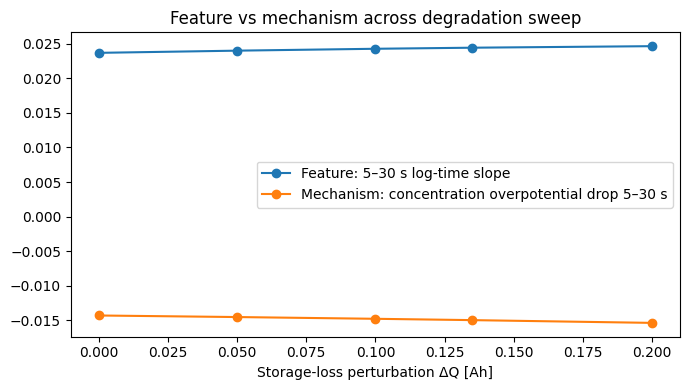

In [67]:
plt.figure(figsize=(7, 4))
plt.plot(
    comparison_mech["delta_q_ah"],
    comparison_mech["log_time_slope_5_30_V_per_log_s"],
    marker="o",
    label="Feature: 5–30 s log-time slope"
)
plt.plot(
    comparison_mech["delta_q_ah"],
    comparison_mech["Concentration overpotential [V]__drop_5_30s"],
    marker="o",
    label="Mechanism: concentration overpotential drop 5–30 s"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.title("Feature vs mechanism across degradation sweep")
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
comparison_mech.corr(numeric_only=True)

,delta_q_ah,log_time_slope_5_30_V_per_log_s,Concentration overpotential [V]__drop_5_30s
delta_q_ah,1.000000,0.990649,-0.997729
log_time_slope_5_30_V_per_log_s,0.990649,1.000000,-0.979215
Concentration overpotential [V]__drop_5_30s,-0.997729,-0.979215,1.000000


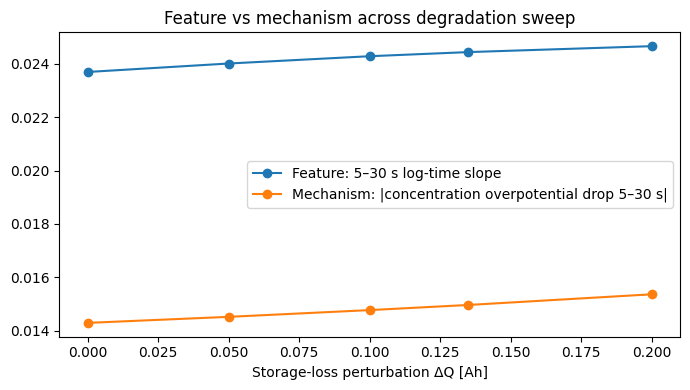

In [69]:
comparison_mech["abs_conc_drop_5_30s"] = -comparison_mech["Concentration overpotential [V]__drop_5_30s"]

plt.figure(figsize=(7, 4))
plt.plot(
    comparison_mech["delta_q_ah"],
    comparison_mech["log_time_slope_5_30_V_per_log_s"],
    marker="o",
    label="Feature: 5–30 s log-time slope"
)
plt.plot(
    comparison_mech["delta_q_ah"],
    comparison_mech["abs_conc_drop_5_30s"],
    marker="o",
    label="Mechanism: |concentration overpotential drop 5–30 s|"
)

plt.xlabel("Storage-loss perturbation ΔQ [Ah]")
plt.title("Feature vs mechanism across degradation sweep")
plt.legend()
plt.tight_layout()
plt.show()